<a href="https://colab.research.google.com/github/lassieo/Yelp---Restaurants-in-New-Orleans/blob/main/dsba_6211_master_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Orleans Restaurants: What Predicts A Strong Yelp Rating?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lassieo/Yelp---Restaurants-in-New-Orleans/blob/main/DSBA_6211_Master_Notebook.ipynb)

New Orleans is a good city for this question because restaurants do not compete on food alone. Some sit in tourist-heavy ZIP codes with constant visitor traffic. Others serve more local neighborhoods. Yelp ratings, review counts, check-ins, and restaurant attributes all get tangled together.

So we start with one plain question:

**What signals line up with a strong current Yelp rating for New Orleans restaurants?**

In this notebook, **restaurant success means current Yelp star rating**. The model predicts `stars`, the 1.0-to-5.0 business rating. For summaries, we use this helper language:

- **High success:** `stars >= 4.0`
- **Lower rated:** `stars < 3.5`
- **Middle group:** `stars == 3.5`

Review count and check-ins matter, but they are not success by themselves. They are attention and activity signals. A restaurant can be famous, busy, or easy for tourists to find without being the highest rated. That distinction is the thread running through the notebook.

## Research Questions This Notebook Can Support

| Question | How this notebook handles it |
|---|---|
| RQ1: What does the New Orleans restaurant market look like? | Ratings, review counts, and ZIP concentration. |
| RQ2: Does price range predict restaurant success? | Price range is compared against `stars` and included in the model. |
| RQ3: Does competition density affect ratings? | Competition density is checked as a ZIP-level market signal. |
| RQ4: What do reviews reveal about high- vs. low-rated restaurants? | We use review count, review frequency, and check-ins here. Sentiment and word-cloud outputs need their own verified files before they become final evidence. |
| RQ5: What combination of features best predicts overall star rating? | This is the main modeling question: linear regression baseline vs. random forest regression. |
| RQ6: Do newer vs. established restaurants differ in what drives success? | This needs a business-age or first-review-date feature before we can answer it honestly. |

That table is the notebook contract. If a planned analysis is not backed by a usable column or file yet, we keep it visible without pretending it is finished.

## How To Read This Notebook

Start with the target, then follow the evidence.

1. **Define success.** We use Yelp `stars` as the main measure of restaurant success. A 4.0+ rating is the simple high-success cutoff for summaries.
2. **Check what data is ready.** The notebook loads the prepared restaurant-level feature table and shows which features can be used right now.
3. **Separate quality from visibility.** Ratings, review counts, review frequency, and check-ins are related, but they do not mean the same thing.
4. **Model the current rating.** Linear regression gives us a simple baseline. Random forest checks whether nonlinear patterns add value.
5. **Name what is still missing.** Sentiment, word-cloud language, topic modeling, and business-age comparisons can be added when the matching files are ready.

The goal is to walk the reader through the work without making unfinished pieces sound finished.

In [ ]:
# Core imports and display settings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
FEATURE_PATH = "https://raw.githubusercontent.com/lassieo/Yelp---Restaurants-in-New-Orleans/main/feature_engineering.csv"
WEEK2_PATH = "https://raw.githubusercontent.com/lassieo/Yelp---Restaurants-in-New-Orleans/main/week2_feature_table.csv"


print(f"Project root: {PROJECT_ROOT}")
# print(f"Final feature table exists: {FEATURE_PATH.exists()} -> {FEATURE_PATH.name}")
# print(f"Week 2 feature table exists: {WEEK2_PATH.exists()} -> {WEEK2_PATH.name}")

Project root: /content


## Which Table Are We Trusting?

Before modeling, we need to know which table is carrying the story.

This notebook uses `feature_engineering.csv` because it is the most complete restaurant-level feature table available in the repository. It has one row per restaurant after deduplication. The older `week2_feature_table.csv` is still useful history, but it has duplicate business IDs, so it is not the clean modeling table.

Read the next table as a trust check: row counts, column counts, and duplicate IDs first; modeling comes later.

In [ ]:
df_raw = pd.read_csv(FEATURE_PATH)
week2 = pd.read_csv(WEEK2_PATH)

# Keep one row per business. The final feature file already satisfies this;
# the check is kept visible so the modeling sample is auditable.
df = df_raw.drop_duplicates(subset="business_id").copy()

# Clean ZIP for grouping and charts. It is not used as a numeric model feature.
df["postal_code_clean"] = (
    df["postal_code"]
    .astype("Int64")
    .astype(str)
    .replace("<NA>", "Unknown")
)

snapshot = pd.DataFrame(
    [
        {"file": "feature_engineering.csv", "rows": len(df_raw), "columns": df_raw.shape[1], "duplicate_business_ids": int(df_raw["business_id"].duplicated().sum())},
        {"file": "week2_feature_table.csv", "rows": len(week2), "columns": week2.shape[1], "duplicate_business_ids": int(week2["business_id"].duplicated().sum())},
    ]
)

display(snapshot)
display(df.head())

,file,rows,columns,duplicate_business_ids
0,feature_engineering.csv,2236,14,0
1,week2_feature_table.csv,2261,11,25


,business_id,stars,review_count,review_frequency,avg_sentiment,checkin_count,price_range,takeout,delivery,reservations,outdoor_seating,good_for_kids,postal_code,competition_density,postal_code_clean
0,YNjyv0gfOr2g8lbmUpTnKg,4.5,350,1.053512,0.0,282.0,2.0,1,1,1,1,0,70112.0,173.0,70112
1,TLZ3-eDPLhUzfsWO4ad6Ug,4.0,382,1.536458,0.0,404.0,2.0,1,0,0,0,1,70112.0,173.0,70112
2,FRYkg_JvsWU9xIXZsEZcVA,3.5,27,3.157895,0.0,22.0,3.0,0,0,1,1,0,70115.0,267.0,70115
3,4IcB3QyMEA85UTWFKh9O9A,4.5,8,10.909091,0.0,7.0,1.0,0,0,0,0,0,70119.0,214.0,70119
4,Edg22x3CZkIv0GUib2oEFA,3.5,149,0.194085,0.0,564.0,2.0,1,1,1,1,1,70118.0,165.0,70118


## Which Features Earn A Place In The Model?

A feature moves forward only if it is present, understandable, and usable without giving the model the answer.

| Feature | Plain-English meaning | Final use here |
|---|---|---|
| `stars` | Current Yelp business rating | Target. This is the main success measure. |
| `review_count` | Total Yelp reviews for the business | Visibility signal and predictor. |
| `review_frequency` | Reviews per active month | Engagement signal and predictor. |
| `checkin_count` | Yelp check-in timestamps for the business | Rough activity signal and predictor. |
| `competition_density` | Number of restaurants in the same ZIP-code market | Market-context predictor. |
| `price_range` | Yelp price tier from 1 to 4 | Restaurant-positioning predictor. |
| `takeout`, `delivery`, `reservations`, `outdoor_seating`, `good_for_kids` | Cleaned yes/no attributes | Service-attribute predictors. |
| `avg_sentiment` | Intended review-text sentiment | Waiting on real sentiment output. Current values are constant zero, so it is excluded. |

The point is not to ban text features. The point is to wait until the sentiment column is real and varied before letting it influence the model.

In [ ]:
provenance = pd.DataFrame(
    [
        ["review_frequency", "week3.py review-date aggregation", "included", df["review_frequency"].nunique(dropna=False)],
        ["checkin_count", "week3.py check-in timestamp count", "included", df["checkin_count"].nunique(dropna=False)],
        ["competition_density", "week2 feature table ZIP-level restaurant count", "included", df["competition_density"].nunique(dropna=False)],
        ["price_range", "Yelp business attributes", "included", df["price_range"].nunique(dropna=False)],
        ["service attributes", "Yelp business attributes", "included", "binary fields"],
        ["avg_sentiment", "placeholder in current feature table", "excluded", df["avg_sentiment"].nunique(dropna=False) if "avg_sentiment" in df.columns else "missing"],
    ],
    columns=["feature", "source", "final_model_status", "distinct_values"],
)
display(provenance)

,feature,source,final_model_status,distinct_values
0,review_frequency,week3.py review-date aggregation,included,1651
1,checkin_count,week3.py check-in timestamp count,included,801
2,competition_density,week2 feature table ZIP-level restaurant count,included,24
3,price_range,Yelp business attributes,included,4
4,service attributes,Yelp business attributes,included,binary fields
5,avg_sentiment,placeholder in current feature table,excluded,1


## Where Success Enters The Notebook

The success definition is simple, but it needs one guardrail.

We can describe high-success restaurants as `stars >= 4.0`. That is useful for tables and plain-English interpretation. But the model itself predicts `stars` directly.

Why be careful? Because if we create `success_label` from `stars`, then use `stars` as an input to predict `success_label`, the model is being handed the answer. That is leakage.

So the rule is:

**Use `stars` as the target. Do not use `stars` as a feature for any label derived from `stars`.**

In [ ]:
# Optional descriptive label only. This is not the model target.
df["success_label"] = np.where(df["stars"] >= 4.0, 1, np.where(df["stars"] < 3.5, 0, np.nan))

FINAL_TARGET = "stars"
FINAL_FEATURES = [
    "review_count",
    "review_frequency",
    "checkin_count",
    "price_range",
    "takeout",
    "delivery",
    "reservations",
    "outdoor_seating",
    "good_for_kids",
    "competition_density",
]

# If a future side classifier is added, this assertion documents the rule:
# stars may never be used as an input to a label derived from stars.
SUCCESS_CLASSIFIER_FEATURES = [c for c in FINAL_FEATURES if c != "stars"]
assert "stars" not in SUCCESS_CLASSIFIER_FEATURES
assert FINAL_TARGET not in FINAL_FEATURES

print(f"Target: {FINAL_TARGET}")
print(f"Final feature count: {len(FINAL_FEATURES)}")
print(FINAL_FEATURES)

Target: stars
Final feature count: 10
['review_count', 'review_frequency', 'checkin_count', 'price_range', 'takeout', 'delivery', 'reservations', 'outdoor_seating', 'good_for_kids', 'competition_density']


## Where The Sentiment Analysis Belongs

Sentiment belongs after the feature check and before the final model comparison.

The workflow is:

1. Start with the cleaned review text for New Orleans restaurants.
2. Score each review with a text-only method such as VADER.
3. Aggregate those review-level scores to one row per restaurant.
4. Merge the restaurant-level sentiment table into the final feature table by `business_id`.
5. Re-run the model twice: once without sentiment, once with sentiment.
6. Compare whether sentiment improves RMSE, MAE, or R2.

That comparison matters. Sentiment is probably related to rating, but the notebook should show whether it adds anything beyond review count, check-ins, price, and attributes. It should also document that sentiment came from review text, not from review star labels.

A full sentiment table should include:

| Needed column | Why it matters |
|---|---|
| `business_id` | Merge key back to the restaurant-level feature table. |
| `avg_sentiment` | Average review-text sentiment for each restaurant. |
| `sentiment_variance` | Whether reviews are consistently positive or mixed. |
| `avg_review_length` | Whether detailed reviews differ by rating group. |
| `positive_review_share` | Share of reviews with clearly positive language. |
| `negative_review_share` | Share of reviews with clearly negative language. |
| `review_text_count` | Number of reviews used to compute the text features. |

Until that table exists and has variation, sentiment should be described as planned or partial work, not final model evidence.

In [ ]:
sentiment_cols = [c for c in df.columns if "sentiment" in c.lower()]
sentiment_audit = []
for col in sentiment_cols:
    sentiment_audit.append(
        {
            "column": col,
            "non_null": int(df[col].notna().sum()),
            "distinct_values": int(df[col].nunique(dropna=False)),
            "min": df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "max": df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "final_model_use": "excluded" if df[col].nunique(dropna=False) <= 1 else "needs source verification",
        }
    )

display(pd.DataFrame(sentiment_audit))

,column,non_null,distinct_values,min,max,final_model_use
0,avg_sentiment,2236,1,0.0,0.0,excluded


## RQ1: What Does The Restaurant Market Look Like?

Start with the shape of the city. Ratings tell us perceived quality. Review counts tell us attention. ZIP codes tell us where restaurants cluster.

The key thing to watch: ratings are packed into a narrow range, while review counts stretch far to the right. A few restaurants get a huge amount of attention. Most restaurants live in a much quieter part of Yelp.

In [ ]:
landscape = pd.DataFrame(
    {
        "metric": [
            "restaurants in final feature table",
            "restaurants with 10+ reviews",
            "mean stars",
            "median stars",
            "mean review_count",
            "median review_count",
            "max review_count",
            "share rated 4.0+",
        ],
        "value": [
            len(df),
            int((df["review_count"] >= 10).sum()),
            round(df["stars"].mean(), 3),
            round(df["stars"].median(), 3),
            round(df["review_count"].mean(), 1),
            round(df["review_count"].median(), 1),
            int(df["review_count"].max()),
            f"{(df['stars'].ge(4.0).mean() * 100):.1f}%",
        ],
    }
)
display(landscape)

top_zips = (
    df.groupby("postal_code_clean", as_index=False)
    .agg(
        restaurants=("business_id", "count"),
        mean_stars=("stars", "mean"),
        median_reviews=("review_count", "median"),
    )
    .sort_values("restaurants", ascending=False)
    .head(10)
    .round(2)
)
display(top_zips)

,metric,value
0,restaurants in final feature table,2236
1,restaurants with 10+ reviews,1961
2,mean stars,3.744
3,median stars,4.0
4,mean review_count,205.4
5,median review_count,57.5
6,max review_count,7568
7,share rated 4.0+,58.3%


,postal_code_clean,restaurants,mean_stars,median_reviews
24,70130,593,3.69,91.0
10,70115,264,3.85,88.0
11,70116,223,3.93,103.0
14,70119,212,3.79,55.0
7,70112,172,3.74,56.5
13,70118,162,3.69,69.0
12,70117,144,4.10,46.5
18,70124,69,3.62,53.0
8,70113,58,3.99,51.5
19,70125,57,3.68,35.0


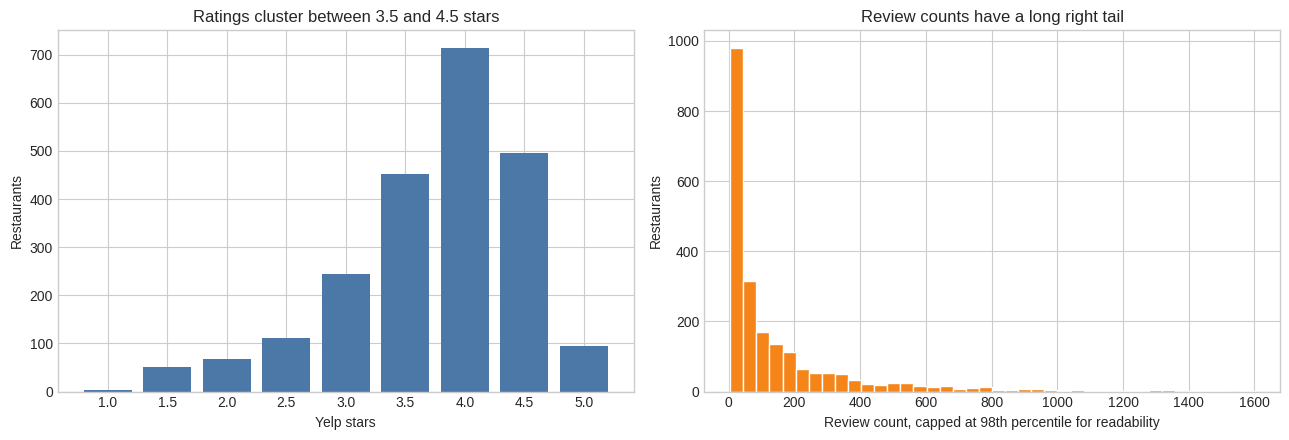

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

star_counts = df["stars"].value_counts().sort_index()
axes[0].bar(star_counts.index.astype(str), star_counts.values, color="#4C78A8")
axes[0].set_title("Ratings cluster between 3.5 and 4.5 stars")
axes[0].set_xlabel("Yelp stars")
axes[0].set_ylabel("Restaurants")

upper = df["review_count"].quantile(0.98)
axes[1].hist(df.loc[df["review_count"] <= upper, "review_count"], bins=40, color="#F58518", edgecolor="white")
axes[1].set_title("Review counts have a long right tail")
axes[1].set_xlabel("Review count, capped at 98th percentile for readability")
axes[1].set_ylabel("Restaurants")

plt.tight_layout()
plt.show()

## RQ2 And RQ3: Price And Competition

Now we test two business-context ideas.

Price range asks whether more expensive restaurants tend to have higher ratings. Competition density asks whether crowded ZIP codes behave differently from less crowded ones.

Neither one proves cause. They are context signals. The job here is to see whether they carry useful information before the model combines them with engagement and activity features.

In [ ]:
price_summary = (
    df.groupby("price_range", dropna=False, as_index=False)
    .agg(
        restaurants=("business_id", "count"),
        mean_stars=("stars", "mean"),
        median_stars=("stars", "median"),
        median_reviews=("review_count", "median"),
    )
    .round(2)
)

competition_bins = pd.qcut(df["competition_density"], q=4, duplicates="drop")
competition_summary = (
    df.assign(competition_quartile=competition_bins.astype(str))
    .groupby("competition_quartile", observed=True, as_index=False)
    .agg(
        restaurants=("business_id", "count"),
        mean_stars=("stars", "mean"),
        median_reviews=("review_count", "median"),
    )
    .round(2)
)

corr_evidence = (
    df[["stars", "price_range", "competition_density", "review_count", "review_frequency", "checkin_count"]]
    .corr(numeric_only=True)["stars"]
    .sort_values(ascending=False)
    .round(3)
    .reset_index()
    .rename(columns={"index": "feature", "stars": "correlation_with_stars"})
)

display(price_summary)
display(competition_summary)
display(corr_evidence)

,price_range,restaurants,mean_stars,median_stars,median_reviews
0,1.0,629,3.49,3.50,30.0
1,2.0,1441,3.84,4.00,79.0
2,3.0,152,3.79,4.00,189.5
3,4.0,14,4.21,4.25,27.5


,competition_quartile,restaurants,mean_stars,median_reviews
0,"(0.999, 144.0]",609,3.68,32.0
1,"(144.0, 214.0]",546,3.75,60.0
2,"(214.0, 602.0]",1080,3.78,90.5
3,nan,1,4.50,7.0


,feature,correlation_with_stars
0,stars,1.000
1,price_range,0.180
2,review_count,0.105
3,review_frequency,0.078
4,checkin_count,0.062
5,competition_density,0.009


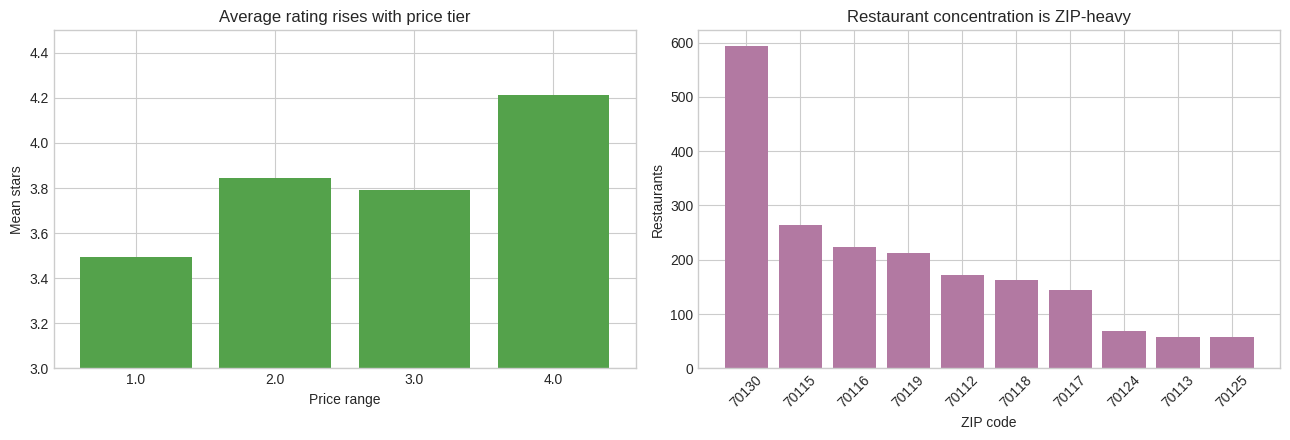

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

price_plot = df.groupby("price_range")["stars"].mean().sort_index()
axes[0].bar(price_plot.index.astype(str), price_plot.values, color="#54A24B")
axes[0].set_title("Average rating rises with price tier")
axes[0].set_xlabel("Price range")
axes[0].set_ylabel("Mean stars")
axes[0].set_ylim(3.0, 4.5)

zip_plot = top_zips.copy()
axes[1].bar(zip_plot["postal_code_clean"].astype(str), zip_plot["restaurants"], color="#B279A2")
axes[1].set_title("Restaurant concentration is ZIP-heavy")
axes[1].set_xlabel("ZIP code")
axes[1].set_ylabel("Restaurants")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## RQ4: What Do Reviews Contribute Right Now?

Right now, the review-derived fields in the final table are total review count and review frequency. Check-ins add a separate activity signal.

These are not the same as sentiment. They tell us how much customer activity a restaurant has around it, not whether the review language is positive or negative. That distinction keeps the notebook honest while leaving a clear place for text mining once the real outputs are added.

In [ ]:
engagement_by_rating = (
    df.assign(
        rating_group=np.where(
            df["stars"] >= 4.0,
            "4.0+ stars",
            np.where(df["stars"] < 3.5, "below 3.5 stars", "3.5 stars"),
        )
    )
    .groupby("rating_group", as_index=False)
    .agg(
        restaurants=("business_id", "count"),
        median_review_count=("review_count", "median"),
        median_review_frequency=("review_frequency", "median"),
        median_checkins=("checkin_count", "median"),
    )
    .round(2)
)

rating_order = {"4.0+ stars": 0, "3.5 stars": 1, "below 3.5 stars": 2}
engagement_by_rating = (
    engagement_by_rating
    .assign(sort_order=engagement_by_rating["rating_group"].map(rating_order))
    .sort_values("sort_order")
    .drop(columns="sort_order")
)
display(engagement_by_rating)

,rating_group,restaurants,median_review_count,median_review_frequency,median_checkins
1,4.0+ stars,1304,74.5,0.39,109.5
0,3.5 stars,453,75.0,0.29,159.0
2,below 3.5 stars,479,23.0,0.15,55.0


## RQ5: Can The Available Features Predict Current Rating?

Now the notebook moves from description to prediction.

The baseline model is linear regression: simple, readable, and limited. The random forest is the stronger test because it can pick up nonlinear patterns and feature interactions.

The claim stays bounded: we are predicting the current Yelp rating snapshot. We are not proving what causes quality, and we are not forecasting future restaurant survival.

In [ ]:
# Modeling sample: keep businesses with at least 10 reviews so the target is based on
# a minimum amount of public rating evidence.
model_df = df[df["review_count"] >= 10].copy()
X = model_df[FINAL_FEATURES]
y = model_df[FINAL_TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    "Mean baseline": None,
    "Linear Regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=500, min_samples_leaf=5, random_state=42, n_jobs=-1)),
        ]
    ),
}

results = []
predictions = {}

for name, model in models.items():
    if model is None:
        y_pred = np.repeat(y_train.mean(), len(y_test))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append(
        {
            "model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred),
        }
    )

model_results = pd.DataFrame(results).sort_values("RMSE").round(3)
display(model_results)

best_model = models["Random Forest"]
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

,model,RMSE,MAE,R2
2,Random Forest,0.580,0.454,0.273
1,Linear Regression,0.648,0.514,0.092
0,Mean baseline,0.687,0.548,-0.018


Training rows: 1,568
Test rows: 393


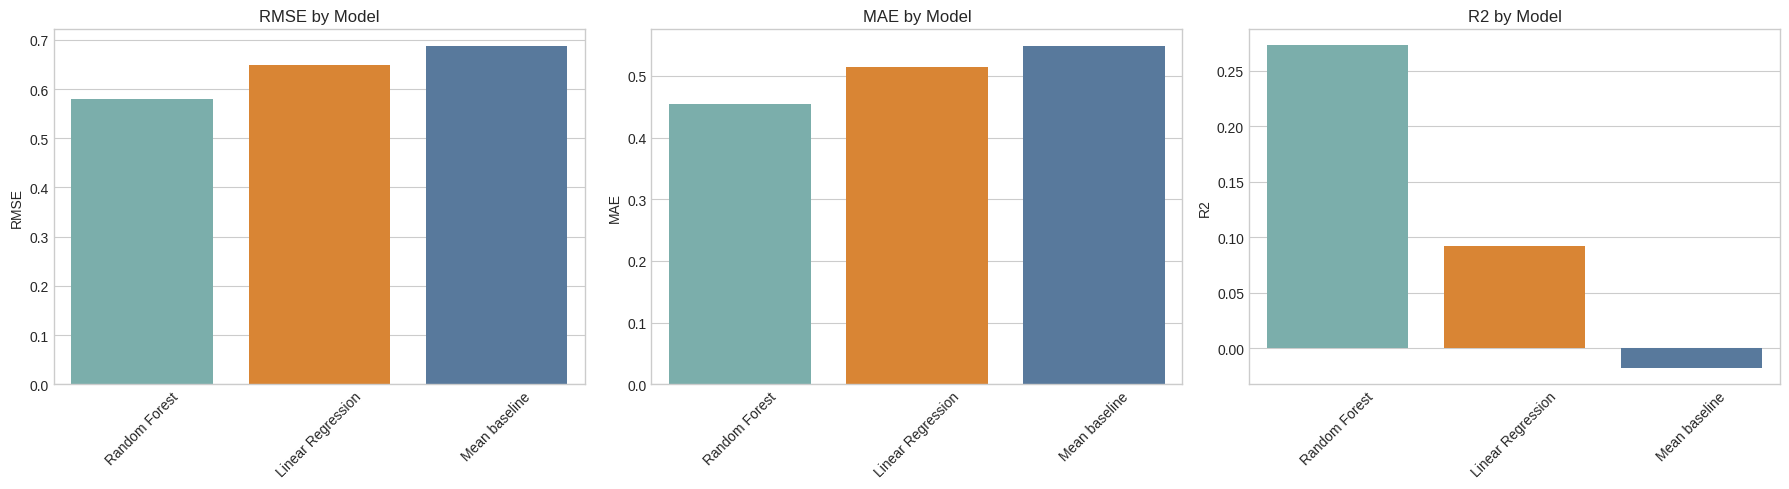

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSE', 'MAE', 'R2']
colors = ['#4C78A8', '#F58518', '#72B7B2']

# Map models to colors for consistent plotting across subplots
model_colors = {'Mean baseline': colors[0], 'Linear Regression': colors[1], 'Random Forest': colors[2]}

for i, metric in enumerate(metrics):
    sns.barplot(x='model', y=metric, data=model_results, ax=axes[i], palette=model_colors, hue='model', legend=False)
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

,feature,importance
0,review_frequency,0.278
1,checkin_count,0.190
2,review_count,0.176
3,competition_density,0.117
4,price_range,0.074
5,delivery,0.060
6,good_for_kids,0.045
7,outdoor_seating,0.035
8,reservations,0.013
9,takeout,0.011


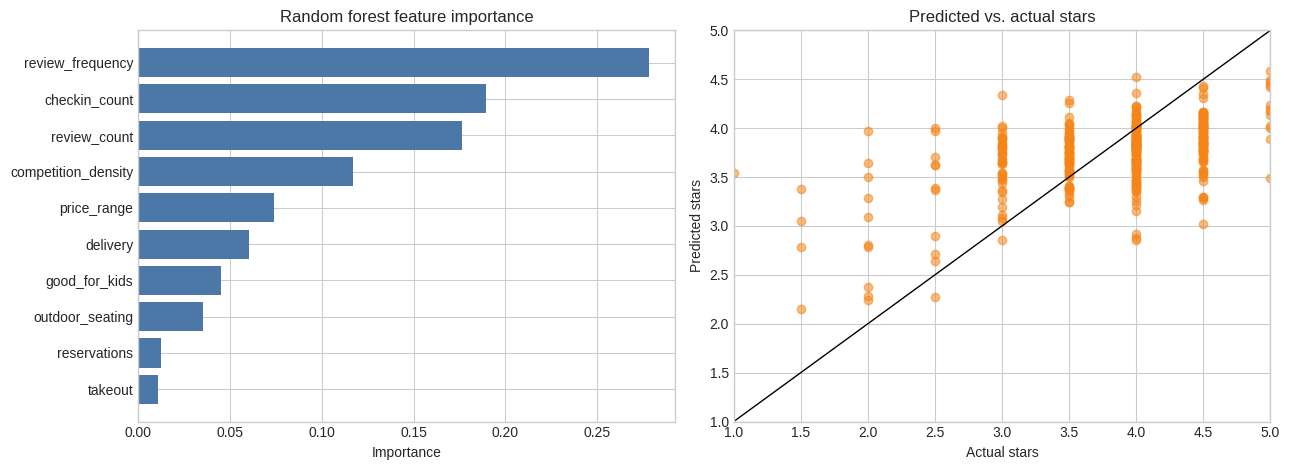

In [ ]:
rf = best_model.named_steps["model"]
importances = (
    pd.Series(rf.feature_importances_, index=FINAL_FEATURES)
    .sort_values(ascending=False)
    .rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(importances.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].barh(importances["feature"], importances["importance"], color="#4C78A8")
axes[0].invert_yaxis()
axes[0].set_title("Random forest feature importance")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")

axes[1].scatter(y_test, predictions["Random Forest"], alpha=0.55, color="#F58518")
axes[1].plot([1, 5], [1, 5], color="black", linewidth=1)
axes[1].set_title("Predicted vs. actual stars")
axes[1].set_xlabel("Actual stars")
axes[1].set_ylabel("Predicted stars")
axes[1].set_xlim(1, 5)
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.show()

## RQ6: What About Newer Vs. Established Restaurants?

This is a good business question, but it needs a real time feature.

The current final table does not include first review date, opening date, or restaurant age. So the notebook does not force the comparison. It simply marks the requirement: add a verified age feature first, then compare whether the same drivers matter for newer and established restaurants.

In [ ]:
age_ready_columns = [
    c for c in df.columns
    if any(token in c.lower() for token in ["first", "open", "age", "date", "year"])
]
age_readiness = pd.DataFrame(
    {
        "needed_feature": ["first_review_date or opening_date"],
        "available_time_columns": [", ".join(age_ready_columns) if age_ready_columns else "none in final feature table"],
        "what_this_means": ["business-age comparison should wait until a verified age feature is added"],
    }
)
display(age_readiness)

,needed_feature,available_time_columns,what_this_means
0,first_review_date or opening_date,none in final feature table,business-age comparison should wait until a ve...


## What Is Missing For The Full Project

The current notebook gives a solid story for the feature table that is ready today. To answer every research question completely, the project still needs a few files and columns added.

| Research question | Current status | Missing for full answer |
|---|---|---|
| RQ1: Restaurant market | Mostly covered with ratings, review counts, and ZIP concentration. | Optional: richer neighborhood labels or cuisine categories. |
| RQ2: Price range and success | Covered as a descriptive table and model feature. | Optional: formal significance test or model coefficient discussion. |
| RQ3: Competition density | Covered as ZIP-level density, correlation, and model feature. | Optional: better geographic competition measure using distance or cuisine type. |
| RQ4: Review text patterns | Partially covered through review activity features. | Needed: verified sentiment table, word frequencies or TF-IDF terms, and examples of positive vs. negative language. |
| RQ5: Best prediction of star rating | Covered for structured, engagement, check-in, and competition features. | Needed: rerun model with verified sentiment/text features and compare against the current model. |
| RQ6: Newer vs. established restaurants | Not fully covered. | Needed: first review date, opening date, or business age feature; then compare ratings and drivers by age group. |

The biggest missing pieces are text features and business age. Once those are added, the notebook can answer the review-language and newer-vs-established questions without stretching beyond the evidence.

## Final Takeaways

Here is the final read:

1. **Restaurant success is mainly current Yelp rating.** The model predicts `stars`, and 4.0+ is the high-success summary cutoff.
2. **Visibility is different from quality.** Review count, review frequency, and check-ins show attention and activity, not guaranteed excellence.
3. **The current model is a snapshot model.** It explains current ratings from available restaurant-level features.
4. **Random forest beats the linear baseline in this notebook.** That suggests nonlinear patterns matter, but feature importance is still not causation.
5. **Text mining belongs here once the outputs are ready.** Sentiment, word clouds, TF-IDF, topics, and review length should be added once their verified outputs are available.
6. **The leakage rule is explicit.** A `success` label can be described from `stars`, but `stars` cannot be used as an input to predict that derived label.

The reader should leave with one clean idea: Yelp success in New Orleans is partly about customer experience and partly about visibility. This notebook separates those two ideas before modeling them together.